# 半监督学习算法 ACC 曲线

本 Notebook 专用于 CIFAR-10、CNN、Dirichlet(20, 0.1)、`double` 设置下的半监督学习实验。

对比算法：SAGE、FedMatch 和 ProxyFL-SSL。FedTest 暂不纳入。结果文件中的 `acc` 已按百分比记录。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.unicode_minus": False,
})

In [2]:
# 兼容从仓库根目录或 plot 目录启动 Jupyter。
current_dir = Path.cwd()
project_root = (
    current_dir.parent if current_dir.name == "plot" else current_dir
)
results_root = project_root / "results"
figures_dir = project_root / "plot" / "figures"

result_files = {
    "SAGE": (
        results_root / "sage/cifar10_cnn_dirichlet_20_0.1/"
        "1_64_0.01_0_0_double_2_0.1_1_0.95_1_0.pt"
    ),
    "FedMatch": (
        results_root / "fedmatch/cifar10_cnn_dirichlet_20_0.1/"
        "1_64_0.01_0_0_double_2_0.1_1_0.95_0.95_10_2_10_"
        "0.01_0.01_10_1e-05_5e-05_5e-05_0.2_0.pt"
    ),
    "ProxyFL-SSL": (
        results_root / "proxyfl_ssl/cifar10_cnn_dirichlet_20_0.1/"
        "1_64_0.01_0_0_double_2_0.1_1_0.95_1_0.01_100_"
        "10_100_0.99_0.pt"
    ),
}

missing_files = [str(path) for path in result_files.values() if not path.is_file()]
if missing_files:
    raise FileNotFoundError("找不到结果文件：\n" + "\n".join(missing_files))

print(f"项目目录：{project_root}")
print("已找到结果：")
for algorithm, path in result_files.items():
    print(f"  {algorithm}: {path.relative_to(project_root)}")

项目目录：/home/dhf/codes/fl
已找到结果：
  SAGE: results/sage/cifar10_cnn_dirichlet_20_0.1/1_64_0.01_0_0_double_2_0.1_1_0.95_1_0.pt
  FedMatch: results/fedmatch/cifar10_cnn_dirichlet_20_0.1/1_64_0.01_0_0_double_2_0.1_1_0.95_0.95_10_2_10_0.01_0.01_10_1e-05_5e-05_5e-05_0.2_0.pt
  ProxyFL-SSL: results/proxyfl_ssl/cifar10_cnn_dirichlet_20_0.1/1_64_0.01_0_0_double_2_0.1_1_0.95_1_0.01_100_10_100_0.99_0.pt


In [3]:
def load_accuracy(path):
    metrics = torch.load(path, map_location="cpu", weights_only=True)
    accuracy = np.asarray(metrics["acc"], dtype=float)
    if accuracy.size == 0:
        raise ValueError(f"结果文件没有 acc 数据：{path}")
    return accuracy

accuracy_data = {
    algorithm: load_accuracy(path)
    for algorithm, path in result_files.items()
}

print("各算法轮数：")
for algorithm, accuracy in accuracy_data.items():
    print(f"  {algorithm}: {len(accuracy)} 轮")

各算法轮数：
  SAGE: 1000 轮
  FedMatch: 1000 轮
  ProxyFL-SSL: 1000 轮


/tmp/ipykernel_1545985/238862894.py:14: UserWarning: Glyph 36890 (\N{CJK UNIFIED IDEOGRAPH-901A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1545985/238862894.py:14: UserWarning: Glyph 20449 (\N{CJK UNIFIED IDEOGRAPH-4FE1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1545985/238862894.py:14: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1545985/238862894.py:14: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1545985/238862894.py:14: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1545985/238862894.py:14: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1545985/238862894.py:14: UserWarning: Glyph 20934 (\N{CJK UNIFIED I

曲线已保存：/home/dhf/codes/fl/plot/figures/ssl_acc_comparison.png


/home/dhf/codes/fl/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dhf/codes/fl/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dhf/codes/fl/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dhf/codes/fl/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dhf/codes/fl/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 29575 (\N{CJK U

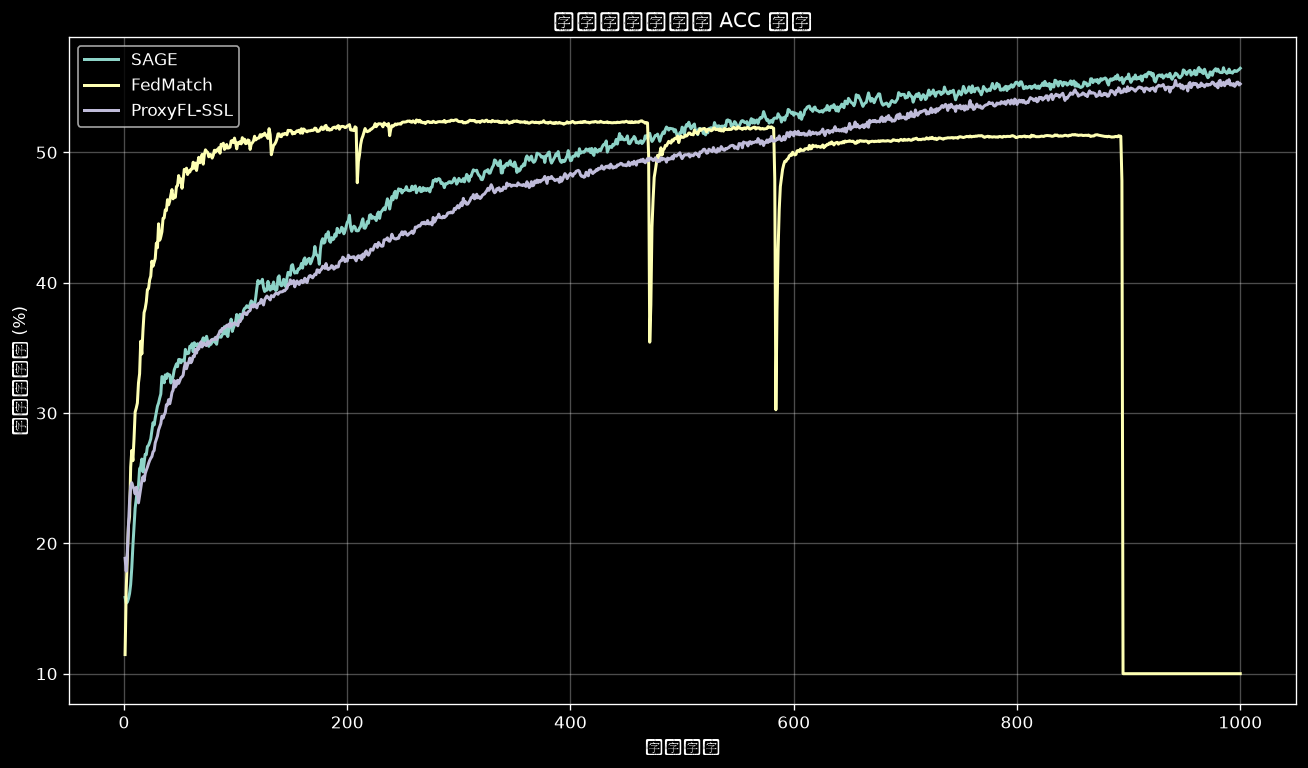

In [4]:
figures_dir.mkdir(parents=True, exist_ok=True)
figure_path = figures_dir / "ssl_acc_comparison.png"

plt.figure(figsize=(11, 6.5))
for algorithm, accuracy in accuracy_data.items():
    rounds = np.arange(1, len(accuracy) + 1)
    plt.plot(rounds, accuracy, linewidth=1.8, label=algorithm)

plt.xlabel("通信轮次")
plt.ylabel("测试准确率 (%)")
plt.title("半监督学习算法 ACC 对比")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
print(f"曲线已保存：{figure_path}")
plt.show()

In [5]:
summary = []
for algorithm, accuracy in accuracy_data.items():
    summary.append({
        "算法": algorithm,
        "最高 ACC (%)": float(np.max(accuracy)),
        "末 10 轮平均 ACC (%)": float(np.mean(accuracy[-10:])),
        "最终 ACC (%)": float(accuracy[-1]),
    })

summary_table = summary
for row in summary_table:
    print(
        f"{row['算法']:<14} "
        f"最高: {row['最高 ACC (%)']:>7.3f}% | "
        f"末10轮平均: {row['末 10 轮平均 ACC (%)']:>7.3f}% | "
        f"最终: {row['最终 ACC (%)']:>7.3f}%"
    )

SAGE           最高:  56.508% | 末10轮平均:  56.237% | 最终:  56.450%
FedMatch       最高:  52.492% | 末10轮平均:  10.000% | 最终:  10.000%
ProxyFL-SSL    最高:  55.575% | 末10轮平均:  55.226% | 最终:  55.250%
